
# 42 — Connected Admissible Region Topology

**Purpose.** This notebook formalizes the step between an admitted resource set and a robust operating design.

The central refinement is:

> A resource is useful only when it belongs to the **largest connected admissible region** that supports computation.

So the notebook does not optimize a single point first. It constructs an admissible region \(\Omega\), extracts its largest connected component \(\Omega_c\), measures margin by distance to the failure boundary \(d(\partial\Omega_c)\), and only then selects an operating point \(x^*\).



## 0. Setup

The notebook is self-contained. It uses only NumPy, Pandas, Matplotlib, and a small connected-component fallback if SciPy is unavailable.


In [1]:

from dataclasses import dataclass
from pathlib import Path
from collections import deque
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import ndimage as ndi
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

OUT = Path('results/figures')
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 14,
    'axes.titlesize': 22,
    'axes.labelsize': 16,
})

print('SciPy available:', SCIPY_AVAILABLE)


SciPy available: True



## 1. Engineering specification chain

The specification chain separates generated resources from admitted topology and robust operation.


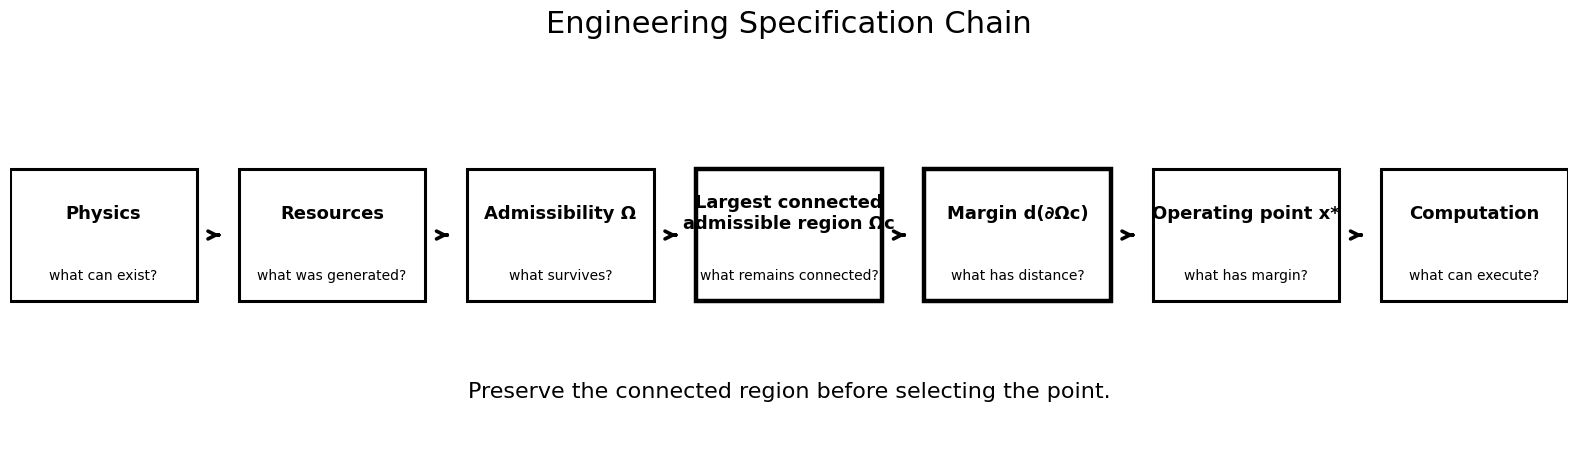

PosixPath('results/figures/42_01_engineering_specification_chain.png')

In [2]:

def draw_spec_chain(filename='42_01_engineering_specification_chain.png'):
    labels = [
        ('Physics', 'what can exist?'),
        ('Resources', 'what was generated?'),
        ('Admissibility Ω', 'what survives?'),
        ('Largest connected\nadmissible region Ωc', 'what remains connected?'),
        ('Margin d(∂Ωc)', 'what has distance?'),
        ('Operating point x*', 'what has margin?'),
        ('Computation', 'what can execute?'),
    ]
    fig, ax = plt.subplots(figsize=(16, 4.8))
    ax.axis('off')
    xs = np.linspace(0.06, 0.94, len(labels))
    y = 0.55
    box_w, box_h = 0.12, 0.34
    for i, ((title, sub), x) in enumerate(zip(labels, xs)):
        lw = 3.2 if 'Ωc' in title else 2.2
        ax.add_patch(plt.Rectangle((x-box_w/2, y-box_h/2), box_w, box_h, fill=False, lw=lw, color='black'))
        ax.text(x, y+0.055, title, ha='center', va='center', fontweight='bold', fontsize=13)
        ax.text(x, y-0.105, sub, ha='center', va='center', fontsize=10)
        if i < len(labels)-1:
            ax.annotate('', xy=(xs[i+1]-box_w/2-0.012, y), xytext=(x+box_w/2+0.012, y),
                        arrowprops=dict(arrowstyle='->', lw=2.6))
    ax.text(0.5, 0.13, 'Preserve the connected region before selecting the point.', ha='center', fontsize=16)
    ax.set_title('Engineering Specification Chain', pad=20)
    fig.tight_layout()
    path = OUT / filename
    fig.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    return path

draw_spec_chain()



## 2. Candidate designs and admissibility model

This is an engineering toy model, not a device claim. The goal is to encode a reusable computational pattern:

1. generate a score field over candidate operating coordinates,
2. threshold it into an admissible mask,
3. extract connected components,
4. measure robustness margins.

Coordinates:

- \(x\): squeezing / nonlinear interaction drive
- \(y\): optical loss / instability pressure


In [3]:

@dataclass(frozen=True)
class CandidateDesign:
    name: str
    drive_center: float
    loss_tolerance: float
    width_x: float
    width_y: float
    fragmentation: float
    detection_support: float
    timing_support: float
    cost: float
    complexity: float

candidates = [
    CandidateDesign('single cavity',        0.62, 0.20, 0.28, 0.20, 0.18, 0.45, 0.35, 2, 2),
    CandidateDesign('coupled resonators',   0.60, 0.24, 0.34, 0.23, 0.12, 0.55, 0.42, 4, 4),
    CandidateDesign('programmable mesh',    0.58, 0.30, 0.42, 0.28, 0.08, 0.70, 0.62, 7, 7),
    CandidateDesign('hybrid chip',          0.62, 0.36, 0.50, 0.34, 0.04, 0.82, 0.75, 9, 8),
]

N = 260
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)


def admissibility_field(design: CandidateDesign):
    '''Return a smooth score field A(x,y) in [0,1].'''
    # Main operating basin: centered in drive, limited by loss/instability.
    basin_x = np.exp(-((X - design.drive_center) ** 2) / (2 * design.width_x ** 2))
    basin_y = np.exp(-((Y - design.loss_tolerance * 0.55) ** 2) / (2 * design.width_y ** 2))

    # Under-drive failure and over-drive instability.
    underdrive = 1 / (1 + np.exp(-(X - 0.28) / 0.045))
    overdrive = 1 / (1 + np.exp((X - 0.98) / 0.04))

    # Loss pressure: higher loss reduces admissibility.
    loss_pressure = np.exp(-Y / max(design.loss_tolerance, 0.05))

    # Support terms widen the useful region.
    support = 0.55 + 0.25 * design.detection_support + 0.20 * design.timing_support

    # Fragmentation introduces small holes / weak patches.
    pattern = 0.5 + 0.5 * np.sin(8*np.pi*X) * np.sin(6*np.pi*Y)
    fragmentation_penalty = 1 - design.fragmentation * pattern

    A = support * basin_x * basin_y * underdrive * overdrive
    A = 0.70 * A + 0.30 * loss_pressure * underdrive * overdrive
    A = A * fragmentation_penalty
    return np.clip(A, 0, 1)

threshold = 0.35
fields = {d.name: admissibility_field(d) for d in candidates}

print('candidate fields:', list(fields))


candidate fields: ['single cavity', 'coupled resonators', 'programmable mesh', 'hybrid chip']



## 3. Topology functions

These functions are the reusable core of the notebook.


In [4]:

def connected_components(mask):
    '''Return labels and component count for a boolean mask.'''
    mask = np.asarray(mask, dtype=bool)
    if SCIPY_AVAILABLE:
        structure = np.ones((3,3), dtype=int)
        labels, n = ndi.label(mask, structure=structure)
        return labels, int(n)

    labels = np.zeros(mask.shape, dtype=int)
    label = 0
    rows, cols = mask.shape
    for r in range(rows):
        for c in range(cols):
            if not mask[r, c] or labels[r, c] != 0:
                continue
            label += 1
            q = deque([(r, c)])
            labels[r, c] = label
            while q:
                rr, cc = q.popleft()
                for dr in (-1,0,1):
                    for dc in (-1,0,1):
                        if dr == 0 and dc == 0:
                            continue
                        nr, nc = rr+dr, cc+dc
                        if 0 <= nr < rows and 0 <= nc < cols and mask[nr,nc] and labels[nr,nc] == 0:
                            labels[nr,nc] = label
                            q.append((nr,nc))
    return labels, label


def largest_component(mask):
    labels, n = connected_components(mask)
    if n == 0:
        return np.zeros_like(mask, dtype=bool), labels, 0
    sizes = np.bincount(labels.ravel())
    sizes[0] = 0
    k = int(np.argmax(sizes))
    return labels == k, labels, n


def distance_inside(mask):
    '''Distance to the nearest failure boundary from inside a mask.'''
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return np.zeros(mask.shape, dtype=float)
    if SCIPY_AVAILABLE:
        dist = ndi.distance_transform_edt(mask)
    else:
        # Simple fallback: repeated erosions approximate distance.
        dist = np.zeros(mask.shape, dtype=float)
        current = mask.copy()
        step = 0
        while current.any():
            step += 1
            boundary = current.copy()
            eroded = current.copy()
            for r in range(1, current.shape[0]-1):
                for c in range(1, current.shape[1]-1):
                    eroded[r,c] = current[r-1:r+2, c-1:c+2].all()
            boundary &= ~eroded
            dist[boundary] = step
            current = eroded
    if dist.max() > 0:
        dist = dist / dist.max()
    return dist


def max_margin_point(mask):
    dist = distance_inside(mask)
    idx = np.unravel_index(np.argmax(dist), dist.shape)
    return idx, float(dist[idx]), dist


def evaluate_design(design, alpha=1.0, beta=0.85, gamma=0.025, delta=0.020):
    field = admissibility_field(design)
    mask = field >= threshold
    comp, labels, ncomp = largest_component(mask)
    idx, margin, dist = max_margin_point(comp)
    area = comp.mean()
    score = alpha*area + beta*margin - gamma*design.cost - delta*design.complexity
    return {
        'design': design.name,
        'area': area,
        'max_margin': margin,
        'components': ncomp,
        'cost': design.cost,
        'complexity': design.complexity,
        'score': score,
        'x_star': x[idx[1]],
        'y_star': y[idx[0]],
        'field': field,
        'mask': mask,
        'component': comp,
        'distance': dist,
    }

results = [evaluate_design(d) for d in candidates]
summary = pd.DataFrame([{k:v for k,v in r.items() if k not in ('field','mask','component','distance')} for r in results])
summary = summary.sort_values('score', ascending=False).reset_index(drop=True)
summary


,design,area,max_margin,components,cost,complexity,score,x_star,y_star
0,single cavity,0.152411,1.0,1,2,2,0.912411,0.621622,0.0
1,coupled resonators,0.208047,1.0,1,4,4,0.878047,0.629344,0.0
2,hybrid chip,0.382707,1.0,1,9,8,0.847707,0.629344,0.0
3,programmable mesh,0.291228,1.0,1,7,7,0.826228,0.625483,0.0



## 4. Region growth: topology first

The next figure shows the idea before the equations: a design becomes more useful when the admissible set remains connected and expands.


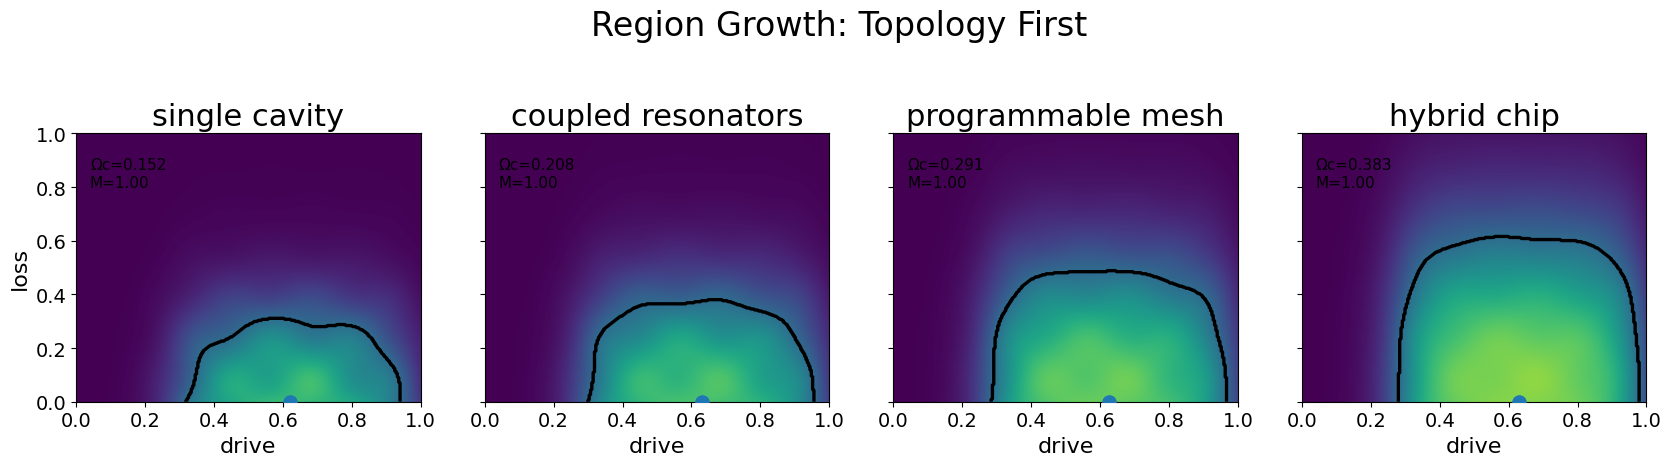

PosixPath('results/figures/42_02_region_growth_topology_first.png')

In [5]:

def plot_region_growth(filename='42_02_region_growth_topology_first.png'):
    selected = ['single cavity', 'coupled resonators', 'programmable mesh', 'hybrid chip']
    fig, axes = plt.subplots(1, 4, figsize=(17, 4.5), sharex=True, sharey=True)
    for ax, name in zip(axes, selected):
        r = next(rr for rr in results if rr['design'] == name)
        ax.imshow(r['field'], origin='lower', extent=[0,1,0,1], vmin=0, vmax=1, aspect='auto')
        ax.contour(X, Y, r['component'].astype(float), levels=[0.5], colors='black', linewidths=2.4)
        ax.scatter([r['x_star']], [r['y_star']], s=90, zorder=3)
        ax.set_title(name)
        ax.text(0.04, 0.91, f"Ωc={r['area']:.3f}\nM={r['max_margin']:.2f}", transform=ax.transAxes,
                va='top', ha='left', fontsize=11)
        ax.set_xlabel('drive')
    axes[0].set_ylabel('loss')
    fig.suptitle('Region Growth: Topology First', y=1.04, fontsize=24)
    fig.tight_layout()
    path = OUT / filename
    fig.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    return path

plot_region_growth()



## 5. Distance transform selects the operating point

The maximum-margin operating point is selected **inside** the connected component, not on the original unfiltered field.


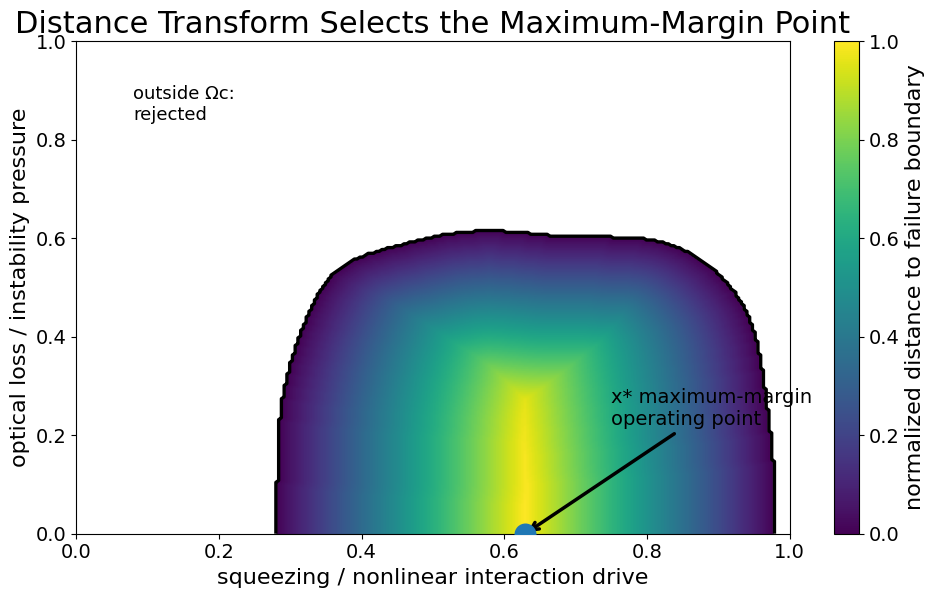

PosixPath('results/figures/42_03_distance_transform_selects_operating_point.png')

In [6]:

def plot_distance_transform(design_name='hybrid chip', filename='42_03_distance_transform_selects_operating_point.png'):
    r = next(rr for rr in results if rr['design'] == design_name)
    fig, ax = plt.subplots(figsize=(10, 6.2))
    masked = np.ma.masked_where(~r['component'], r['distance'])
    im = ax.imshow(masked, origin='lower', extent=[0,1,0,1], vmin=0, vmax=1, aspect='auto')
    ax.contour(X, Y, r['component'].astype(float), levels=[0.5], colors='black', linewidths=2.4)
    ax.scatter([r['x_star']], [r['y_star']], s=220, zorder=4)
    ax.annotate('x* maximum-margin\noperating point', xy=(r['x_star'], r['y_star']),
                xytext=(min(r['x_star']+0.12, 0.82), min(r['y_star']+0.22, 0.9)),
                arrowprops=dict(arrowstyle='->', lw=2.5), fontsize=14)
    ax.text(0.08, 0.84, 'outside Ωc:\nrejected', transform=ax.transAxes, fontsize=13)
    ax.set_title('Distance Transform Selects the Maximum-Margin Point')
    ax.set_xlabel('squeezing / nonlinear interaction drive')
    ax.set_ylabel('optical loss / instability pressure')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('normalized distance to failure boundary')
    fig.tight_layout()
    path = OUT / filename
    fig.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    return path

plot_distance_transform()



## 6. Region-constrained objective

A point objective is trailing. The leading design object is the connected admissible region.

\[
J(D)=\alpha |\Omega_c(D)| + \beta M(D) - \gamma C(D) - \delta K(D)
\]

where:

- \(|\Omega_c|\): largest connected admissible area,
- \(M\): maximum robustness margin,
- \(C\): hardware cost,
- \(K\): control complexity.


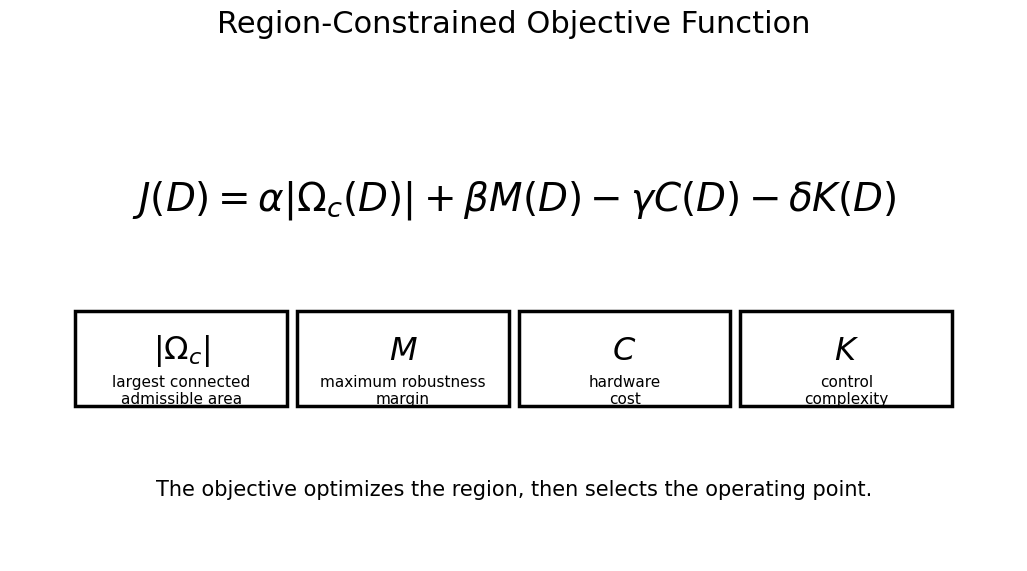

PosixPath('results/figures/42_04_region_constrained_objective.png')

In [7]:

def plot_objective_spec(filename='42_04_region_constrained_objective.png'):
    fig, ax = plt.subplots(figsize=(13, 6.5))
    ax.axis('off')
    ax.set_title('Region-Constrained Objective Function', pad=20)
    ax.text(0.5, 0.72, r'$J(D)=\alpha |\Omega_c(D)| + \beta M(D) - \gamma C(D) - \delta K(D)$',
            ha='center', va='center', fontsize=28)
    boxes = [
        (r'$|\Omega_c|$', 'largest connected\nadmissible area'),
        (r'$M$', 'maximum robustness\nmargin'),
        (r'$C$', 'hardware\ncost'),
        (r'$K$', 'control\ncomplexity'),
    ]
    xs = np.linspace(0.17, 0.83, 4)
    for x0, (top, bottom) in zip(xs, boxes):
        ax.add_patch(plt.Rectangle((x0-0.105, 0.31), 0.21, 0.19, fill=False, lw=2.5))
        ax.text(x0, 0.42, top, ha='center', va='center', fontsize=23, fontweight='bold')
        ax.text(x0, 0.34, bottom, ha='center', va='center', fontsize=11)
    ax.text(0.5, 0.13, 'The objective optimizes the region, then selects the operating point.', ha='center', fontsize=15)
    path = OUT / filename
    fig.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    return path

plot_objective_spec()



## 7. Candidate architecture comparison

The best design is not necessarily the cheapest or the locally highest-scoring point. It is the design that preserves the best connected admissible region after cost and complexity penalties.


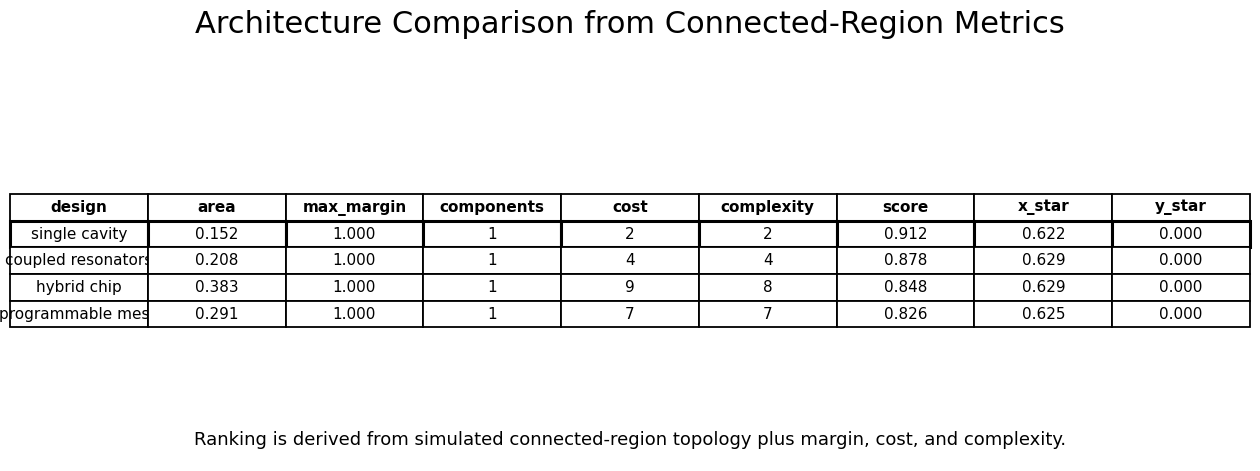

PosixPath('results/figures/42_05_architecture_comparison_table.png')

In [8]:

def plot_summary_table(filename='42_05_architecture_comparison_table.png'):
    df = summary.copy()
    df_display = df[['design','area','max_margin','components','cost','complexity','score','x_star','y_star']].copy()
    for col in ['area','max_margin','score','x_star','y_star']:
        df_display[col] = df_display[col].map(lambda v: f'{v:.3f}')
    fig, ax = plt.subplots(figsize=(16, 5.2))
    ax.axis('off')
    ax.set_title('Architecture Comparison from Connected-Region Metrics', pad=20)
    table = ax.table(cellText=df_display.values, colLabels=df_display.columns,
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.6)
    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(1.3)
        if row == 0:
            cell.set_text_props(fontweight='bold')
        if row == 1:
            cell.set_linewidth(2.2)
    ax.text(0.5, 0.04, 'Ranking is derived from simulated connected-region topology plus margin, cost, and complexity.',
            ha='center', fontsize=13)
    path = OUT / filename
    fig.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    return path

plot_summary_table()



## 8. Sensitivity: which refinement expands the connected region?

A region-first search asks which engineering refinement increases \(|\Omega_c|\), not merely which refinement improves a local point.


In [9]:

def modify_design(design, **updates):
    params = design.__dict__.copy()
    params.update(updates)
    return CandidateDesign(**params)

base = next(d for d in candidates if d.name == 'programmable mesh')
base_eval = evaluate_design(base)
experiments = {
    'loss reduction': modify_design(base, loss_tolerance=base.loss_tolerance+0.06),
    'squeezing support': modify_design(base, width_x=base.width_x+0.06),
    'detection improvement': modify_design(base, detection_support=min(1, base.detection_support+0.12)),
    'timing control': modify_design(base, timing_support=min(1, base.timing_support+0.12)),
    'fragmentation reduction': modify_design(base, fragmentation=max(0, base.fragmentation-0.04)),
    'local optimization': modify_design(base, drive_center=base.drive_center+0.03),
}
rows=[]
for name, d in experiments.items():
    r = evaluate_design(d)
    rows.append({
        'refinement': name,
        'Δ largest connected region': r['area'] - base_eval['area'],
        'Δ margin': r['max_margin'] - base_eval['max_margin'],
        'new score': r['score'],
    })
sens = pd.DataFrame(rows).sort_values('Δ largest connected region', ascending=True)
sens


,refinement,Δ largest connected region,Δ margin,new score
5,local optimization,0.001154,0.0,0.827382
3,timing control,0.004896,0.0,0.831124
4,fragmentation reduction,0.004941,0.0,0.831169
2,detection improvement,0.006021,0.0,0.832249
1,squeezing support,0.006686,0.0,0.832914
0,loss reduction,0.026893,0.0,0.853121


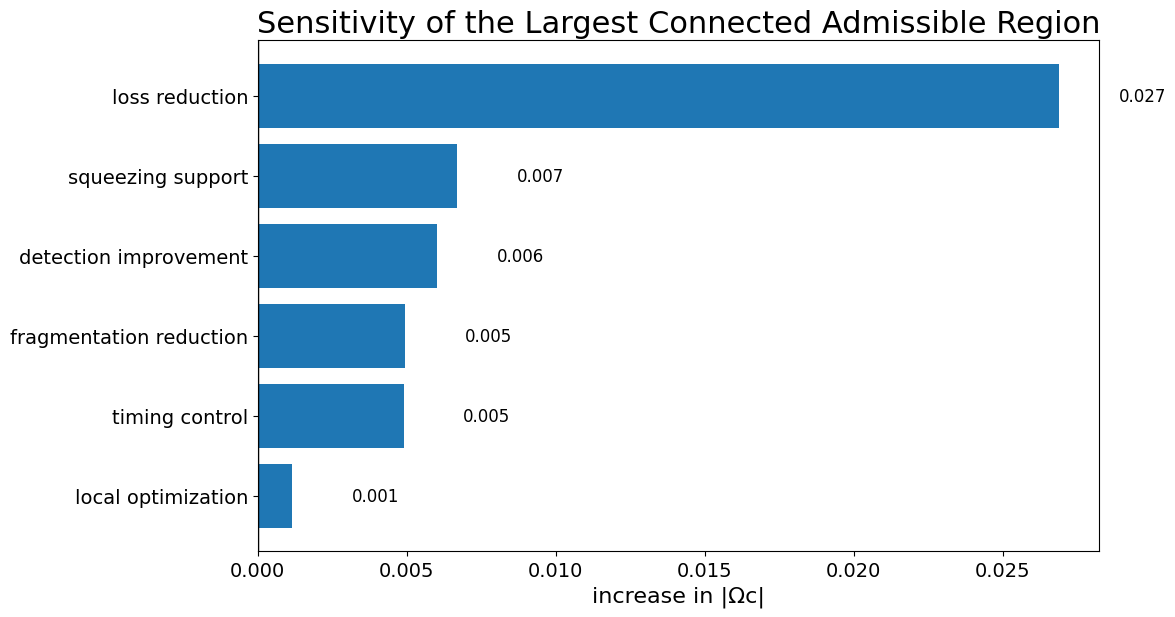

PosixPath('results/figures/42_06_sensitivity_largest_connected_region.png')

In [10]:

def plot_sensitivity(filename='42_06_sensitivity_largest_connected_region.png'):
    fig, ax = plt.subplots(figsize=(12, 6.4))
    labels = sens['refinement']
    vals = sens['Δ largest connected region']
    ax.barh(labels, vals)
    ax.axvline(0, color='black', lw=1)
    for i, v in enumerate(vals):
        ax.text(v + (0.002 if v >= 0 else -0.002), i, f'{v:.3f}', va='center',
                ha='left' if v >= 0 else 'right', fontsize=12)
    ax.set_title('Sensitivity of the Largest Connected Admissible Region')
    ax.set_xlabel('increase in |Ωc|')
    fig.tight_layout()
    path = OUT / filename
    fig.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    return path

plot_sensitivity()



## 9. Point search versus region-constrained search

The workflow below is the core engineering distinction.


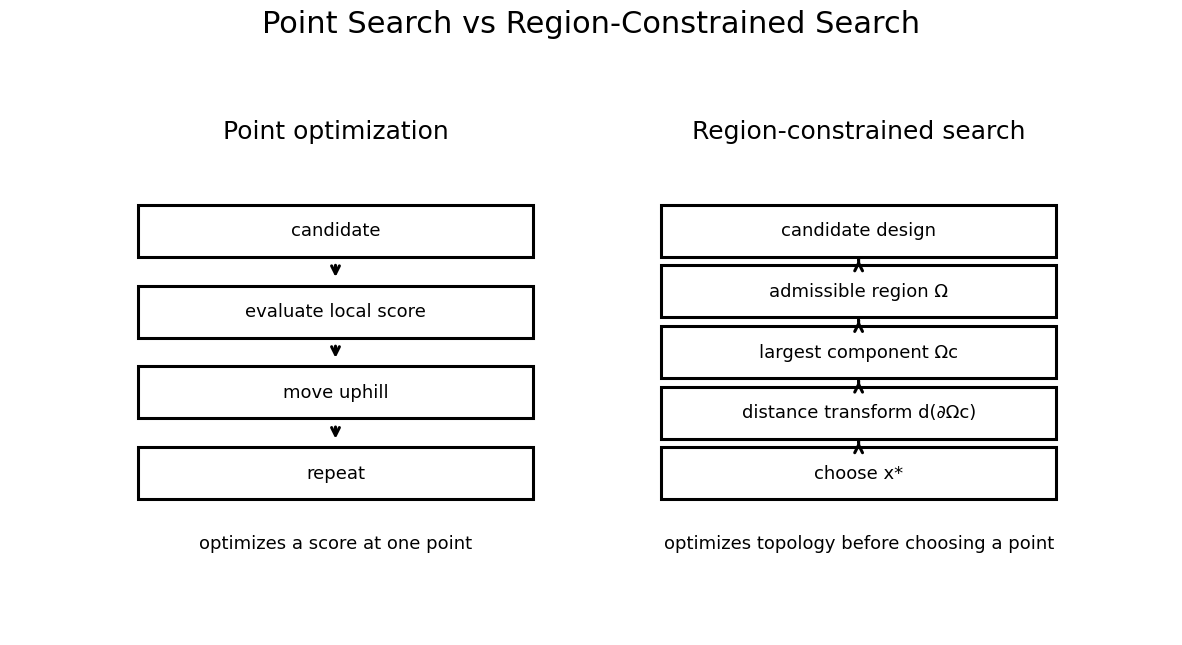

PosixPath('results/figures/42_07_point_vs_region_search.png')

In [11]:

def draw_point_vs_region(filename='42_07_point_vs_region_search.png'):
    fig, ax = plt.subplots(figsize=(15, 7.5))
    ax.axis('off')
    ax.set_title('Point Search vs Region-Constrained Search', pad=18)

    def stack(x0, title, boxes, footer):
        ax.text(x0, 0.86, title, ha='center', fontsize=18)
        ys = np.linspace(0.70, 0.28, len(boxes))
        for i, (y0, label) in enumerate(zip(ys, boxes)):
            ax.add_patch(plt.Rectangle((x0-0.17, y0-0.045), 0.34, 0.09, fill=False, lw=2.2))
            ax.text(x0, y0, label, ha='center', va='center', fontsize=13)
            if i < len(boxes)-1:
                ax.annotate('', xy=(x0, ys[i+1]+0.055), xytext=(x0, y0-0.055),
                            arrowprops=dict(arrowstyle='->', lw=2.2))
        ax.text(x0, 0.15, footer, ha='center', fontsize=13)

    stack(0.28, 'Point optimization',
          ['candidate', 'evaluate local score', 'move uphill', 'repeat'],
          'optimizes a score at one point')
    stack(0.73, 'Region-constrained search',
          ['candidate design', 'admissible region Ω', 'largest component Ωc', 'distance transform d(∂Ωc)', 'choose x*'],
          'optimizes topology before choosing a point')
    path = OUT / filename
    fig.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    return path

draw_point_vs_region()



## 10. Engineering conclusion

The notebook reduces the design rule to one operational test:

> Does the candidate design preserve a large, connected, high-margin admissible region?

If not, a locally attractive operating point is fragile.


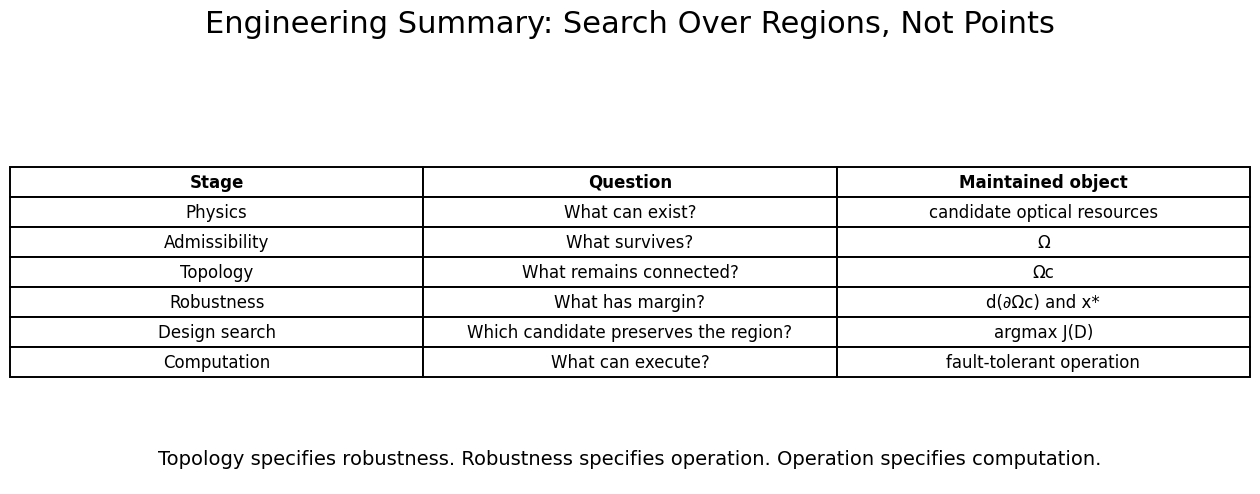

PosixPath('results/figures/42_08_final_region_specification.png')

In [12]:

def draw_final_spec(filename='42_08_final_region_specification.png'):
    rows = [
        ['Physics', 'What can exist?', 'candidate optical resources'],
        ['Admissibility', 'What survives?', 'Ω'],
        ['Topology', 'What remains connected?', 'Ωc'],
        ['Robustness', 'What has margin?', 'd(∂Ωc) and x*'],
        ['Design search', 'Which candidate preserves the region?', 'argmax J(D)'],
        ['Computation', 'What can execute?', 'fault-tolerant operation'],
    ]
    fig, ax = plt.subplots(figsize=(16, 5.5))
    ax.axis('off')
    ax.set_title('Engineering Summary: Search Over Regions, Not Points', pad=20)
    table = ax.table(cellText=rows, colLabels=['Stage','Question','Maintained object'],
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 1.8)
    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(1.4)
        if row == 0:
            cell.set_text_props(fontweight='bold')
    ax.text(0.5, 0.045, 'Topology specifies robustness. Robustness specifies operation. Operation specifies computation.',
            ha='center', fontsize=14)
    path = OUT / filename
    fig.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    return path

draw_final_spec()



## 11. Export summary tables


In [13]:

RESULTS = Path('results')
RESULTS.mkdir(exist_ok=True)
summary.to_csv(RESULTS / '42_connected_region_architecture_summary.csv', index=False)
sens.to_csv(RESULTS / '42_connected_region_sensitivity.csv', index=False)

print('Wrote:')
print(RESULTS / '42_connected_region_architecture_summary.csv')
print(RESULTS / '42_connected_region_sensitivity.csv')
print('Figures:', OUT)


Wrote:
results/42_connected_region_architecture_summary.csv
results/42_connected_region_sensitivity.csv
Figures: results/figures



## Takeaway

Notebook 42 introduces the topology object that later notebooks can reuse:

\[
D \rightarrow \Omega(D) \rightarrow \Omega_c(D) \rightarrow d(\partial\Omega_c) \rightarrow x^*.
\]

The key result is not a single best coordinate. The key result is the connected admissible region that makes a coordinate robust enough to use.
